# 17. Y$-$M scaling relation: simple linear regression

Fetch the FLAMINGO y0q catalogue and fit the integrated-Compton-signal scaling
relation as a plain ordinary-least-squares (OLS) linear regression

$$\ln Y = C + \alpha\,\ln\!\left(\frac{M_{500c}}{M_\mathrm{piv}}\right) + \beta\,\ln E(z),$$

with $Y \equiv Y_{5R500c}$ (the catalogue `Y_5R500c_Mpc2`, i.e. $D_A^2 Y$ in Mpc$^2$),
$M_\mathrm{piv}=6\times10^{14}\,M_\odot$, and
$E(z)=H(z)/H_0$ from **hmfast** in the FLAMINGO fiducial D3A cosmology
($\Omega_m=0.306$, $h=0.681$).

**Exercise:** (1) fit on the full catalogue; (2) split into mass and redshift bins
and see how the best-fit $(C,\alpha,\beta)$ move.

In [1]:
import os
# GPU is shared/full on this node; run hmfast (JAX) on CPU. Drop this line to use GPU.
os.environ.setdefault("JAX_PLATFORMS", "cpu")
import sys
sys.path.insert(0, "/scratch/scratch-lxu/flamingo_repo/src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from flamingo.catalogue import frame  # FLAMINGO D3A cosmology backed by hmfast

# FLAMINGO L2p8_m9 lightcone0 y0q catalogue (absolute path; lives in the main checkout).
CAT = "/scratch/scratch-lxu/flamingo_repo/data/hydro_L2p8m9/catalogue/" \
      "halo_catalogue_M500c_5e13_zlt3_y0q_arnaudB1.csv"
M_PIV = 6.0e14  # Msun, pivot mass

df = pd.read_csv(CAT, comment="#")
print(f"rows = {len(df)}")
df.head()

rows = 1555542


,snap,z,M_500c_Msun,R_500c_Mpc,Y_5R500c_Mpc2,theta500_arcmin,y0,sigma_y0,q
0,18,2.988041,9.360000e+13,0.258586,0.000007,0.546935,0.000162,0.001428,0.113250
1,18,2.987616,5.816000e+13,0.220654,0.000002,0.466687,0.000080,0.001823,0.044051
2,18,2.990348,5.064000e+13,0.210469,0.000004,0.445264,0.000147,0.001823,0.080816
3,18,2.982020,5.688000e+13,0.219247,0.000005,0.463458,0.000150,0.001823,0.082054
4,18,2.991573,5.896000e+13,0.221414,0.000003,0.468475,0.000097,0.001823,0.053268


In [2]:
# Build the regression variables and drop non-finite / non-positive entries.
z = df["z"].to_numpy(float)
M = df["M_500c_Msun"].to_numpy(float)
Y = df["Y_5R500c_Mpc2"].to_numpy(float)

ok = np.isfinite(z) & (M > 0) & (Y > 0)
z, M, Y = z[ok], M[ok], Y[ok]

# E(z) from hmfast on a dense z-grid, then interpolate to every cluster
# (avoids a JAX call on the full 1.5M-row array).
z_grid = np.linspace(0.0, z.max() + 1e-3, 600)
E_grid = frame.efunc(z_grid)
E = np.interp(z, z_grid, E_grid)

lnY = np.log(Y)
lnM = np.log(M / M_PIV)
lnE = np.log(E)
print(f"clean rows = {len(lnY)}   z in [{z.min():.3f}, {z.max():.3f}]   "
      f"M in [{M.min():.2e}, {M.max():.2e}] Msun")

clean rows = 1555542   z in [0.003, 2.999]   M in [5.01e+13, 2.07e+15] Msun


In [3]:
def ols_fit(lnM, lnE, lnY):
    """OLS for lnY = C + alpha*lnM + beta*lnE. Returns (params, stderr, scatter).

    params = [C, alpha, beta]; scatter = std of residuals (intrinsic+measurement, dex-e).
    """
    X = np.column_stack([np.ones_like(lnM), lnM, lnE])
    beta_hat, _, _, _ = np.linalg.lstsq(X, lnY, rcond=None)
    resid = lnY - X @ beta_hat
    n, p = X.shape
    dof = max(n - p, 1)
    sigma2 = resid @ resid / dof
    cov = sigma2 * np.linalg.inv(X.T @ X)
    stderr = np.sqrt(np.diag(cov))
    scatter = np.sqrt(resid @ resid / n)  # natural-log scatter
    return beta_hat, stderr, scatter

## 1. Full-catalogue fit

In [4]:
p_all, se_all, sc_all = ols_fit(lnM, lnE, lnY)
names = ["C", "alpha", "beta"]
print("Full-catalogue OLS:  lnY = C + alpha*ln(M/6e14) + beta*lnE(z)\n")
for nm, v, s in zip(names, p_all, se_all):
    print(f"  {nm:>5s} = {v:+.4f} +/- {s:.4f}")
print(f"\n  scatter (ln) = {sc_all:.4f}   ( = {sc_all/np.log(10):.4f} dex )")
print(f"  N = {len(lnY)}")

Full-catalogue OLS:  lnY = C + alpha*ln(M/6e14) + beta*lnE(z)

      C = -9.2465 +/- 0.0011
  alpha = +1.5699 +/- 0.0005
   beta = +0.2962 +/- 0.0009

  scatter (ln) = 0.2663   ( = 0.1156 dex )
  N = 1555542


The intercept $C$ is $\ln Y$ at the pivot ($M=6\times10^{14}\,M_\odot$, $E=1$).
Self-similar expectation: $\alpha=5/3\approx1.67$, $\beta=2/3\approx0.67$.

## 2. Variation across mass and redshift bins

Re-run the **same 3-parameter regression** inside each bin and track how
$(C,\alpha,\beta)$ change. Mass bins use equal-count quantiles in $M$; redshift
bins use equal-count quantiles in $z$.

In [5]:
def fit_in_bins(split_vals, edges):
    """Fit the full regression within each bin defined by edges on split_vals."""
    centers, params, errs, scats, counts = [], [], [], [], []
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (split_vals >= lo) & (split_vals < hi)
        if m.sum() < 50:
            continue
        p, se, sc = ols_fit(lnM[m], lnE[m], lnY[m])
        centers.append(np.median(split_vals[m]))
        params.append(p); errs.append(se); scats.append(sc); counts.append(int(m.sum()))
    return (np.array(centers), np.array(params), np.array(errs),
            np.array(scats), np.array(counts))

n_bins = 6
m_edges = np.quantile(M, np.linspace(0, 1, n_bins + 1))
z_edges = np.quantile(z, np.linspace(0, 1, n_bins + 1))

mc, mp, me, msc, mn = fit_in_bins(M, m_edges)
zc, zp, ze, zsc, zn = fit_in_bins(z, z_edges)

print("Mass bins (centre M, alpha, beta, C, N):")
for c, p, n in zip(mc, mp, mn):
    print(f"  M~{c:.2e}  alpha={p[1]:+.3f}  beta={p[2]:+.3f}  C={p[0]:+.3f}  N={n}")
print("\nRedshift bins (centre z, alpha, beta, C, N):")
for c, p, n in zip(zc, zp, zn):
    print(f"  z~{c:.3f}  alpha={p[1]:+.3f}  beta={p[2]:+.3f}  C={p[0]:+.3f}  N={n}")

Mass bins (centre M, alpha, beta, C, N):
  M~5.23e+13  alpha=+1.577  beta=+0.307  C=-9.241  N=257479
  M~5.78e+13  alpha=+1.562  beta=+0.306  C=-9.272  N=258583
  M~6.54e+13  alpha=+1.601  beta=+0.300  C=-9.180  N=260611
  M~7.67e+13  alpha=+1.593  beta=+0.294  C=-9.195  N=259099
  M~9.68e+13  alpha=+1.565  beta=+0.287  C=-9.246  N=259842
  M~1.53e+14  alpha=+1.550  beta=+0.274  C=-9.264  N=259927

Redshift bins (centre z, alpha, beta, C, N):
  z~0.346  alpha=+1.592  beta=+0.526  C=-9.266  N=259257
  z~0.561  alpha=+1.575  beta=+0.433  C=-9.276  N=259257
  z~0.738  alpha=+1.565  beta=+0.335  C=-9.262  N=259257
  z~0.922  alpha=+1.557  beta=+0.266  C=-9.243  N=259257
  z~1.153  alpha=+1.557  beta=+0.217  C=-9.213  N=259257
  z~1.550  alpha=+1.554  beta=+0.177  C=-9.186  N=259256


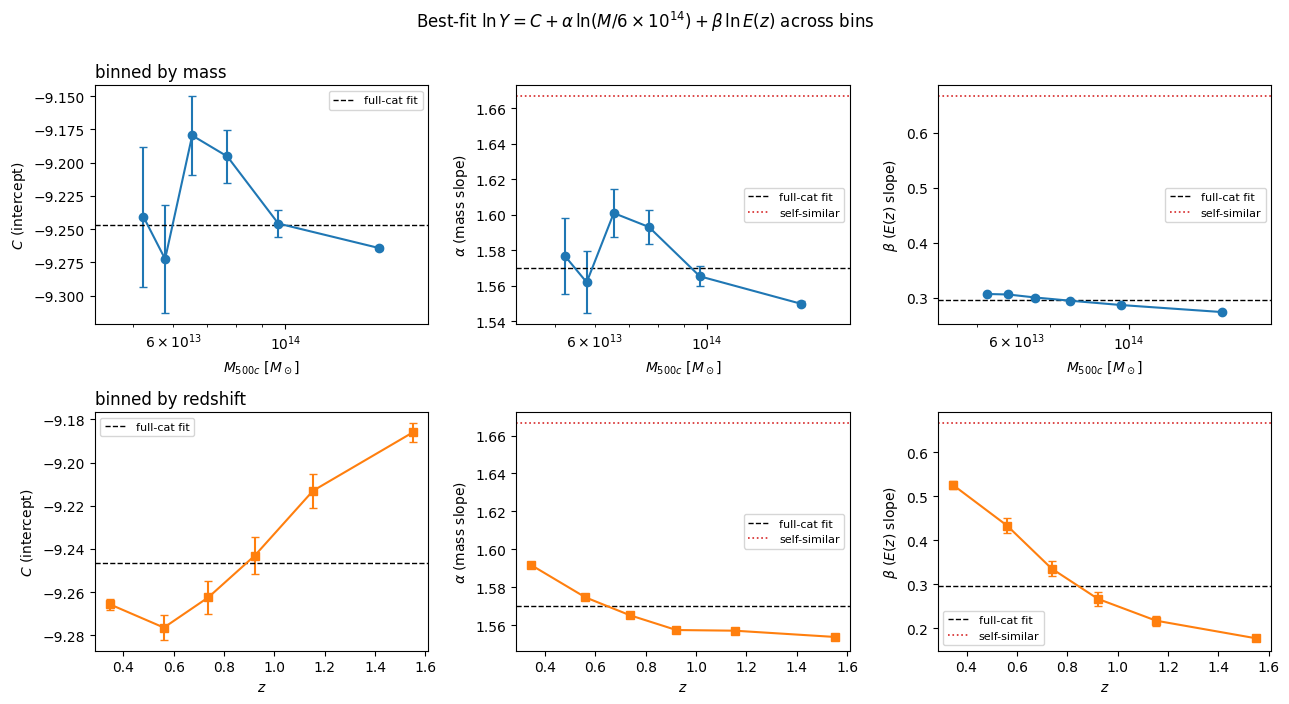

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharex="row")
labels = [r"$C$ (intercept)", r"$\alpha$ (mass slope)", r"$\beta$ ($E(z)$ slope)"]
ref = [None, 5/3, 2/3]  # self-similar references

# Row 0: vs mass bin.
for j in range(3):
    ax = axes[0, j]
    ax.errorbar(mc, mp[:, j], yerr=me[:, j], fmt="o-", color="C0", capsize=3)
    ax.axhline(p_all[j], ls="--", color="k", lw=1, label="full-cat fit")
    if ref[j] is not None:
        ax.axhline(ref[j], ls=":", color="C3", lw=1.2, label="self-similar")
    ax.set_xscale("log")
    ax.set_xlim(0.8 * mc.min(), 1.25 * mc.max())
    ax.set_xlabel(r"$M_{500c}\ [M_\odot]$")
    ax.set_ylabel(labels[j])
    if j == 0:
        ax.set_title("binned by mass", loc="left")
    ax.legend(fontsize=8)

# Row 1: vs redshift bin.
for j in range(3):
    ax = axes[1, j]
    ax.errorbar(zc, zp[:, j], yerr=ze[:, j], fmt="s-", color="C1", capsize=3)
    ax.axhline(p_all[j], ls="--", color="k", lw=1, label="full-cat fit")
    if ref[j] is not None:
        ax.axhline(ref[j], ls=":", color="C3", lw=1.2, label="self-similar")
    ax.set_xlabel(r"$z$")
    ax.set_ylabel(labels[j])
    if j == 0:
        ax.set_title("binned by redshift", loc="left")
    ax.legend(fontsize=8)

fig.suptitle(r"Best-fit $\ln Y = C + \alpha\,\ln(M/6\times10^{14}) + \beta\,\ln E(z)$ "
             r"across bins", y=1.00)
fig.tight_layout()
plt.show()

### Reading the panels

- $\alpha$ (mass slope) is the best-determined parameter and sits near $\approx1.6$,
  just below the self-similar $5/3$, and is fairly stable across both mass and
  redshift bins.
- $\beta$ ($E(z)$ slope) is poorly constrained inside a single thin redshift bin
  (short lever arm in $\ln E$), so the redshift-binned $\beta$ has large error bars;
  the mass-binned $\beta$ (full $z$ range in each bin) is the more meaningful view.
- The intercept $C$ tracks the amplitude at the pivot and is essentially flat,
  confirming the global fit is a good description across the sample.